In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ipums_extracted_v3.csv")
df = df.set_index("STATEFIP")
df

,YEAR,SERIAL,MONTH,HWTFINL,CPSID,ASECFLAG,ASECWTH,PERNUM,WTFINL,CPSIDP,...,OCC50LY,INDLY,OCC90LY,IND90LY,FULLPART,FIRMSIZE,INCTOT,INCWAGE,EDATT,EDATTLY
STATEFIP,,,,,,,,,,,,,,,,,,,,,
6,1988,1,1,NaN,1.987100e+13,NaN,NaN,1,2901.0600,19871000000101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1988,1,1,NaN,1.987100e+13,NaN,NaN,2,2877.9600,19871000000102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1988,1,1,NaN,1.987100e+13,NaN,NaN,3,3152.0400,19871000000103,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,1988,2,1,NaN,1.987100e+13,NaN,NaN,1,1241.0400,19871000000301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,1988,3,1,NaN,1.986100e+13,NaN,NaN,1,1922.3700,19861000000501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,1997,60517,12,299.0424,1.997091e+13,NaN,NaN,2,299.0424,19970906014702,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,1997,60517,12,299.0424,1.997091e+13,NaN,NaN,3,231.2252,19970906014703,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,1997,60517,12,299.0424,1.997091e+13,NaN,NaN,4,210.2731,19970906014704,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
nj_pa_df = df.loc[[34, 42]] # filtering for only NJ and PA state codes
nj_pa_df = nj_pa_df.assign(NJ_PA = lambda x: x.index == 34) # creating treatment indicator by state
nj_pa_df['POLICY_PERIOD'] = nj_pa_df.apply(lambda x: (x['YEAR'] > 1992) or (x['YEAR'] == 1992 and x['MONTH'] > 4), axis = 1) # creating treatment indicator by policy period
# making indicators 1 and 0 
nj_pa_df['NJ_PA'] = nj_pa_df['NJ_PA'].astype(int)
nj_pa_df['POLICY_PERIOD'] = nj_pa_df['POLICY_PERIOD'].astype(int)
nj_pa_df = nj_pa_df.reset_index()

In [4]:
nj_pa_df['DAY'] = 1
nj_pa_df['PERIOD'] = pd.to_datetime(nj_pa_df[['MONTH', 'YEAR', 'DAY']]).dt.to_period('M')
nj_pa_df = nj_pa_df.drop(columns=['DAY', 'MONTH', 'STATEFIP'])
nj_pa_df

,YEAR,SERIAL,HWTFINL,CPSID,ASECFLAG,ASECWTH,PERNUM,WTFINL,CPSIDP,CPSIDV,...,IND90LY,FULLPART,FIRMSIZE,INCTOT,INCWAGE,EDATT,EDATTLY,NJ_PA,POLICY_PERIOD,PERIOD
0,1988,2,NaN,1.987100e+13,NaN,NaN,1,1241.0400,19871000000301,198710000003011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1988-01
1,1988,23,NaN,1.987120e+13,NaN,NaN,1,1537.2900,19871200002201,198712000022011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1988-01
2,1988,92,NaN,1.988010e+13,NaN,NaN,1,1266.4100,19880100009201,198801000092011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1988-01
3,1988,92,NaN,1.988010e+13,NaN,NaN,2,1288.7100,19880100009202,198801000092021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1988-01
4,1988,92,NaN,1.988010e+13,NaN,NaN,3,1212.1600,19880100009203,198801000092031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1988-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519211,1997,48979,1892.5032,1.997110e+13,NaN,NaN,2,1892.5032,19971104892802,199711048928021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1997-12
1519212,1997,48980,2317.6384,1.997110e+13,NaN,NaN,1,2317.6384,19971104892901,199711048929011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1997-12
1519213,1997,48980,2317.6384,1.997110e+13,NaN,NaN,2,2039.9635,19971104892902,199711048929021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1997-12
1519214,1997,48980,2317.6384,1.997110e+13,NaN,NaN,3,2142.6876,19971104892903,199711048929032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1997-12


In [5]:
#SAMPLE of CPS: 1991-1993 window, working at "Eating & Drinking Places" under 641 code in IND1990
nj_pa_cps_sample = nj_pa_df[(nj_pa_df['ASECWT'].isna() == True) & (nj_pa_df['IND1990'] == 641) & (nj_pa_df['EMPSTAT'] >= 10) & (nj_pa_df['EMPSTAT'] <= 12)].reset_index()

state_by_month_cps_sample = nj_pa_cps_sample.groupby(['NJ_PA', 'PERIOD'])['WTFINL'].sum().reset_index()

state_by_month_cps_sample

,NJ_PA,PERIOD,WTFINL
0,0,1988-01,233245.2700
1,0,1988-02,206743.6300
2,0,1988-03,218862.5700
3,0,1988-04,243557.3800
4,0,1988-05,292737.9400
...,...,...,...
235,1,1997-08,195959.2994
236,1,1997-09,170358.7339
237,1,1997-10,179518.6538
238,1,1997-11,164377.2749


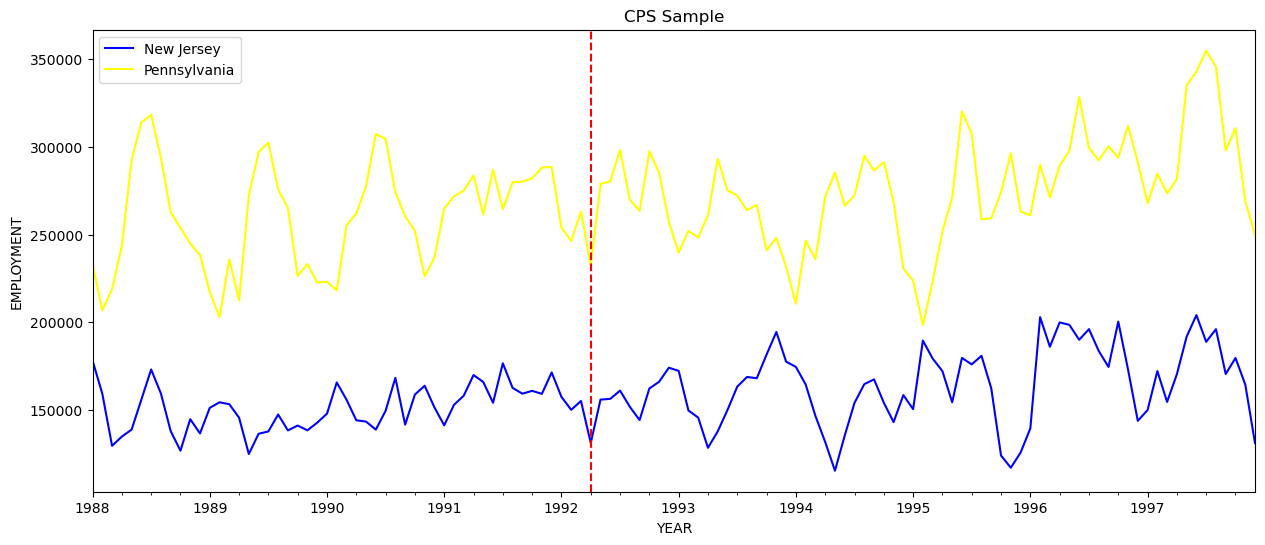

In [124]:
fig, ax = plt.subplots(figsize=(15, 6))

nj_state_by_month_cps_sample = state_by_month_cps_sample[state_by_month_cps_sample.get('NJ_PA') == 1].set_index('PERIOD')
pa_state_by_month_cps_sample = state_by_month_cps_sample[state_by_month_cps_sample.get('NJ_PA') == 0].set_index('PERIOD')

nj_state_by_month_cps_sample.plot(kind='line', y= 'WTFINL', ax = ax, label='New Jersey', color='blue');
pa_state_by_month_cps_sample.plot(kind='line', y= 'WTFINL', ax = ax, label='Pennsylvania', color='yellow');


target_x = pd.Period('1992-04', freq = 'M');
ax.axvline(x=target_x, color='red', linestyle='--', label='Vertical Line');
plt.xlabel('YEAR')
plt.ylabel('EMPLOYMENT')
ax.set_title('CPS Sample');

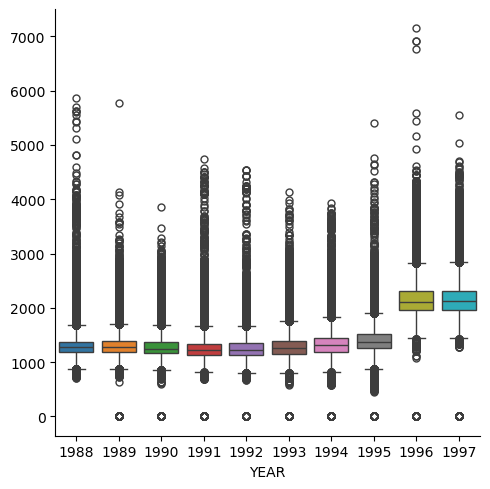

In [154]:
#state_by_month_pre_policy = nj_pa_df.reset_index()
state_by_month_es = nj_pa_df[['YEAR', 'WTFINL', 'NJ_PA']]
nj_state_by_month_es = state_by_month_es[state_by_month_pre_policy.get('NJ_PA') == 1]
nj_state_by_month_es = nj_state_by_month_es.pivot(columns='YEAR', values='WTFINL')
sns.catplot(
    data=nj_state_by_month_es,
    kind="box"
)

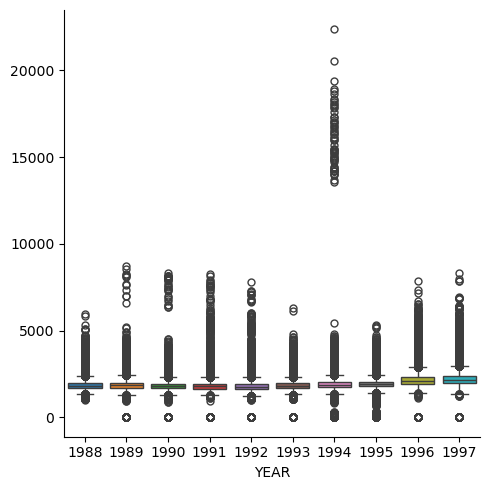

In [155]:
state_by_month_es = nj_pa_df[['YEAR', 'WTFINL', 'NJ_PA']]
pa_state_by_month_es = state_by_month_es[state_by_month_pre_policy.get('NJ_PA') == 0]
pa_state_by_month_es = pa_state_by_month_es.pivot(columns='YEAR', values='WTFINL')
sns.catplot(
    data=pa_state_by_month_es,
    kind="box"
)